# Multi-Agent with Tools - BCAI or OpenAI

Sections 3 and 4 from the RAG notebook, unchanged, except the LLM can now be
**BCAI** or **OpenAI**. Switch with one variable in `.env`.

**VS Code setup**

1. `pip install -r requirements.txt` in the terminal
2. Put `boeing_chat_model.py` next to this notebook (only needed for BCAI)
3. Create a `.env` file (template in the next cell)
4. Click **Select Kernel**, top right, and pick your `.venv`
5. Run the cells top to bottom

## Setup

Create a `.env` file in this folder:

```dotenv
# bcai  or  openai
LLM_PROVIDER=bcai

# for BCAI
UDAL_PAT=your_udal_pat_here
BCAI_MODEL=gpt-4.1-mini

# for OpenAI
OPENAI_API_KEY=sk-...
OPENAI_MODEL=gpt-4o-mini

# optional
OPENWEATHER_API_KEY=
LANGCHAIN_API_KEY=
LANGCHAIN_TRACING_V2=true
LANGCHAIN_PROJECT=multi-agent
```

`requirements.txt`:

```text
langchain-core
langchain-openai
langgraph
langsmith
python-dotenv
requests
httpx
ipykernel
```

In [1]:
# ---------------------------------------------------------------
# Load .env  (keys stay out of the notebook)
# ---------------------------------------------------------------

import os
from dotenv import load_dotenv

load_dotenv(override=True)

PROVIDER = os.getenv("LLM_PROVIDER", "openai").strip().lower()

print(f"[SETUP] Provider: {PROVIDER}")
print(f"[SETUP] UDAL_PAT set      : {'Yes' if os.getenv('UDAL_PAT') else 'No'}")
print(f"[SETUP] OPENAI_API_KEY set: {'Yes' if os.getenv('OPENAI_API_KEY') else 'No'}")

# LangSmith only if a key exists, otherwise it warns on every call
if os.getenv("LANGCHAIN_API_KEY"):
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ.setdefault("LANGCHAIN_PROJECT", "multi-agent")
    print(f"[SETUP] Tracing: ON")
else:
    os.environ["LANGCHAIN_TRACING_V2"] = "false"
    print(f"[SETUP] Tracing: OFF")

[SETUP] Provider: openai
[SETUP] UDAL_PAT set      : No
[SETUP] OPENAI_API_KEY set: Yes
[SETUP] Tracing: OFF


---
## The only new part: one LLM factory

Everything below this cell is your original code. This is the single place
where BCAI and OpenAI differ.

In [2]:
# ---------------------------------------------------------------
# get_llm()  ->  BCAI or OpenAI, decided by LLM_PROVIDER
# Both support .bind_tools() and .invoke(), so the agent code
# below does not change at all.
# ---------------------------------------------------------------

def get_llm(temperature: float = 0):
    """Return a chat model for the active provider."""

    if PROVIDER == "bcai":
        from boeing_chat_model import BoeingChatModel
        return BoeingChatModel(
            udal_pat=os.environ["UDAL_PAT"],
            model=os.getenv("BCAI_MODEL", "gpt-4.1-mini"),
            temperature=temperature,
        )

    from langchain_openai import ChatOpenAI
    return ChatOpenAI(
        model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
        temperature=temperature,
        api_key=os.environ["OPENAI_API_KEY"],
    )


# quick check
from langchain_core.messages import HumanMessage

_llm = get_llm()
print(f"[LLM] {type(_llm).__name__} via {PROVIDER}")
print(f"[LLM] Test: {_llm.invoke([HumanMessage(content='Say OK')]).content.strip()}")

[LLM] ChatOpenAI via openai
[LLM] Test: OK!


---
## SECTION 3 - LangGraph Agent

We build a stateful agent using LangGraph with:
- Weather tool
- Calculator tool
- Wikipedia summary tool
- Input guardrail
- Orchestrator agent that routes between specialized agents

In [3]:
# ---------------------------------------------------------------
# TOOL DEFINITIONS
# ---------------------------------------------------------------

import math
import json
import requests
from langchain_core.tools import tool


@tool
def get_weather(city: str) -> str:
    """
    Get the current weather for a city.
    Returns temperature (Celsius), condition, and humidity.
    """
    print(f"[TOOL: get_weather] Called with city='{city}'")

    api_key = os.environ.get("OPENWEATHER_API_KEY", "")

    if api_key:
        url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
        try:
            resp = requests.get(url, timeout=5)
            data = resp.json()
            if resp.status_code == 200:
                temp = data["main"]["temp"]
                condition = data["weather"][0]["description"]
                humidity = data["main"]["humidity"]
                result = f"Weather in {city}: {temp}C, {condition}, humidity {humidity}%"
                print(f"[TOOL: get_weather] Result: {result}")
                return result
        except Exception as e:
            print(f"[TOOL: get_weather] API call failed: {e}. Using mock data.")

    # Mock data when no API key is available
    mock_data = {
        "london": "Weather in London: 12C, overcast clouds, humidity 78%",
        "new york": "Weather in New York: 18C, clear sky, humidity 55%",
        "tokyo": "Weather in Tokyo: 22C, light rain, humidity 82%",
        "paris": "Weather in Paris: 15C, partly cloudy, humidity 65%",
        "hyderabad": "Weather in Hyderabad: 35C, sunny, humidity 40%",
    }
    result = mock_data.get(city.lower(), f"Weather in {city}: 20C, clear sky, humidity 60% (mock)")
    print(f"[TOOL: get_weather] Mock result: {result}")
    return result


@tool
def calculator(expression: str) -> str:
    """
    Evaluate a mathematical expression safely.
    Examples: '2 + 2', 'sqrt(16)', '100 * 1.08'
    """
    print(f"[TOOL: calculator] Expression: '{expression}'")
    try:
        # Safe evaluation using math functions only
        allowed_names = {k: v for k, v in math.__dict__.items() if not k.startswith("_")}
        allowed_names["abs"] = abs
        result = eval(expression, {"__builtins__": {}}, allowed_names)
        output = f"Result of '{expression}' = {result}"
        print(f"[TOOL: calculator] {output}")
        return output
    except Exception as e:
        error = f"Could not evaluate '{expression}': {str(e)}"
        print(f"[TOOL: calculator] ERROR: {error}")
        return error


@tool
def get_definition(term: str) -> str:
    """
    Return a short definition or explanation of a technical term.
    """
    print(f"[TOOL: get_definition] Term: '{term}'")
    definitions = {
        "rag": "RAG (Retrieval-Augmented Generation) is a technique that combines document retrieval with LLM generation to answer questions using external knowledge.",
        "langchain": "LangChain is a Python/TypeScript framework for building LLM-powered applications with chains, agents, and memory.",
        "langgraph": "LangGraph is a LangChain extension for building stateful multi-actor workflows using a directed graph structure.",
        "embedding": "An embedding is a high-dimensional numerical vector representing the semantic meaning of a piece of text.",
        "faiss": "FAISS (Facebook AI Similarity Search) is an open-source library for efficient similarity search over dense vectors.",
        "agent": "An agent is an LLM-powered system that can choose and call tools autonomously to complete a task.",
        "vector store": "A vector store is a database optimized for storing and retrieving high-dimensional embedding vectors using similarity search.",
    }
    key = term.lower().strip()
    result = definitions.get(key, f"No definition found for '{term}'. Try: rag, langchain, langgraph, embedding, faiss, agent, vector store")
    print(f"[TOOL: get_definition] Result: {result[:80]}...")
    return result


print("[TOOLS] Defined tools:")
print("  - get_weather: Get current weather for a city")
print("  - calculator: Evaluate a math expression")
print("  - get_definition: Get definition of a technical term")

[TOOLS] Defined tools:
  - get_weather: Get current weather for a city
  - calculator: Evaluate a math expression
  - get_definition: Get definition of a technical term


In [4]:
# ---------------------------------------------------------------
# GUARDRAIL - Input Validation
# Block harmful or off-topic queries before the agent runs
# ---------------------------------------------------------------

BLOCKED_KEYWORDS = [
    "bomb", "weapon", "hack", "exploit", "malware", "virus",
    "illegal", "drugs", "nsfw"
]

def guardrail_check(user_input: str) -> tuple:
    """
    Returns (is_safe: bool, reason: str).
    Blocks overly short inputs and known harmful keywords.
    """
    print(f"[GUARDRAIL] Checking input: '{user_input[:80]}'")

    if len(user_input.strip()) < 3:
        print("[GUARDRAIL] BLOCKED - Input too short.")
        return False, "Input is too short. Please provide a meaningful question."

    lower_input = user_input.lower()
    for keyword in BLOCKED_KEYWORDS:
        if keyword in lower_input:
            print(f"[GUARDRAIL] BLOCKED - Harmful keyword detected: '{keyword}'")
            return False, f"Input contains disallowed content: '{keyword}'. This agent cannot assist with such requests."

    print("[GUARDRAIL] PASSED - Input is safe.")
    return True, "OK"


# Test guardrail
print("\n--- Guardrail Tests ---")
print(guardrail_check("What is the weather in London?"))
print(guardrail_check("hi"))
print(guardrail_check("How do I hack a website?"))


--- Guardrail Tests ---
[GUARDRAIL] Checking input: 'What is the weather in London?'
[GUARDRAIL] PASSED - Input is safe.
(True, 'OK')
[GUARDRAIL] Checking input: 'hi'
[GUARDRAIL] BLOCKED - Input too short.
(False, 'Input is too short. Please provide a meaningful question.')
[GUARDRAIL] Checking input: 'How do I hack a website?'
[GUARDRAIL] BLOCKED - Harmful keyword detected: 'hack'
(False, "Input contains disallowed content: 'hack'. This agent cannot assist with such requests.")


In [5]:
# ---------------------------------------------------------------
# LANGGRAPH AGENT
# ---------------------------------------------------------------

from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.messages import SystemMessage
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
import operator

# Bind tools to the LLM
tools = [get_weather, calculator, get_definition]

# CHANGED: was ChatOpenAI(...) -- now provider agnostic
agent_llm = get_llm(temperature=0).bind_tools(tools)

print(f"[AGENT] {type(agent_llm).__name__} initialized and tools bound ({PROVIDER}).")
print(f"[AGENT] Tools available: {[t.name for t in tools]}")


# --- State definition ---
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]


# --- Node: call the LLM ---
def call_llm(state: AgentState) -> AgentState:
    print("\n[NODE: call_llm] Invoking LLM...")
    messages = state["messages"]
    print(f"[NODE: call_llm] Messages in state: {len(messages)}")

    # Prepend system message
    system = SystemMessage(content=(
        "You are a helpful assistant with access to weather, calculator, and definition tools. "
        "Use tools when needed to answer the user's question accurately."
    ))
    response = agent_llm.invoke([system] + messages)

    print(f"[NODE: call_llm] Response type: {type(response).__name__}")
    if response.tool_calls:
        print(f"[NODE: call_llm] Tool calls requested: {[tc['name'] for tc in response.tool_calls]}")
    else:
        print(f"[NODE: call_llm] No tool calls. Final answer: {response.content[:80]}...")

    return {"messages": [response]}


# --- Routing function ---
def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print(f"[ROUTER] Tool calls detected -> routing to 'tools' node")
        return "tools"
    print(f"[ROUTER] No tool calls -> routing to END")
    return END


# --- Build the graph ---
tool_node = ToolNode(tools)

workflow = StateGraph(AgentState)
workflow.add_node("llm", call_llm)
workflow.add_node("tools", tool_node)
workflow.set_entry_point("llm")
workflow.add_conditional_edges("llm", should_continue)
workflow.add_edge("tools", "llm")  # After tool execution, go back to LLM

agent_app = workflow.compile()

print("\n[LANGGRAPH] Agent graph compiled successfully.")
print("[LANGGRAPH] Graph structure:")
print("  Entry -> llm -> (if tool calls) -> tools -> llm -> ... -> END")

[AGENT] _ChatModelBinding initialized and tools bound (openai).
[AGENT] Tools available: ['get_weather', 'calculator', 'get_definition']

[LANGGRAPH] Agent graph compiled successfully.
[LANGGRAPH] Graph structure:
  Entry -> llm -> (if tool calls) -> tools -> llm -> ... -> END


### LangGraph Agent (llm <-> tools)

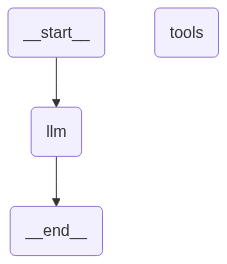

In [6]:
from IPython.display import Image, display, Markdown

def show_langgraph(app, title: str):
    display(Markdown(f"### {title}"))
    graph = app.get_graph()
    try:
        display(Image(graph.draw_mermaid_png()))
    except Exception as e:
        print(f"Could not render PNG ({e}). Showing Mermaid text instead:\n")
        print(graph.draw_mermaid())

# Visualize the agent graph
show_langgraph(agent_app, "LangGraph Agent (llm <-> tools)")

# Visualize orchestrator graph (if already executed)
if "orchestrator_app" in globals():
    show_langgraph(orchestrator_app, "LangGraph Orchestrator")

In [7]:
# ---------------------------------------------------------------
# Run the Agent with Guardrails
# ---------------------------------------------------------------

def run_agent(user_input: str):
    print(f"\n{'='*60}")
    print(f"[AGENT RUN] User input: {user_input}")
    print(f"{'='*60}")

    # Guardrail check
    is_safe, reason = guardrail_check(user_input)
    if not is_safe:
        print(f"\n[GUARDRAIL BLOCKED] {reason}")
        return reason

    # Run LangGraph agent
    initial_state = {"messages": [HumanMessage(content=user_input)]}
    final_state = agent_app.invoke(initial_state)

    # Extract final answer
    final_message = final_state["messages"][-1]
    answer = final_message.content

    print(f"\n[FINAL ANSWER] {answer}")
    return answer


# Test the agent
run_agent("What is the weather like in sydney right now?")


[AGENT RUN] User input: What is the weather like in sydney right now?
[GUARDRAIL] Checking input: 'What is the weather like in sydney right now?'
[GUARDRAIL] PASSED - Input is safe.

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 1
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] Tool calls requested: ['get_weather']
[ROUTER] Tool calls detected -> routing to 'tools' node
[TOOL: get_weather] Called with city='Sydney'
[TOOL: get_weather] Mock result: Weather in Sydney: 20C, clear sky, humidity 60% (mock)

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 3
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] No tool calls. Final answer: The current weather in Sydney is 20°C with a clear sky and humidity at 60%....
[ROUTER] No tool calls -> routing to END

[FINAL ANSWER] The current weather in Sydney is 20°C with a clear sky and humidity at 60%.


'The current weather in Sydney is 20°C with a clear sky and humidity at 60%.'

In [8]:
run_agent("What is 45 /8500, and then multiply that by 3?")


[AGENT RUN] User input: What is 45 /8500, and then multiply that by 3?
[GUARDRAIL] Checking input: 'What is 45 /8500, and then multiply that by 3?'
[GUARDRAIL] PASSED - Input is safe.

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 1
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] Tool calls requested: ['calculator']
[ROUTER] Tool calls detected -> routing to 'tools' node
[TOOL: calculator] Expression: '(45 / 8500) * 3'
[TOOL: calculator] Result of '(45 / 8500) * 3' = 0.01588235294117647

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 3
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] No tool calls. Final answer: The result of \( \frac{45}{8500} \) multiplied by 3 is approximately 0.0159....
[ROUTER] No tool calls -> routing to END

[FINAL ANSWER] The result of \( \frac{45}{8500} \) multiplied by 3 is approximately 0.0159.


'The result of \\( \\frac{45}{8500} \\) multiplied by 3 is approximately 0.0159.'

In [10]:
run_agent("What is Aeroplane? Give me a short definition.")


[AGENT RUN] User input: What is Aeroplane? Give me a short definition.
[GUARDRAIL] Checking input: 'What is Aeroplane? Give me a short definition.'
[GUARDRAIL] PASSED - Input is safe.

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 1
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] Tool calls requested: ['get_definition']
[ROUTER] Tool calls detected -> routing to 'tools' node
[TOOL: get_definition] Term: 'Aeroplane'
[TOOL: get_definition] Result: No definition found for 'Aeroplane'. Try: rag, langchain, langgraph, embedding, ...

[NODE: call_llm] Invoking LLM...
[NODE: call_llm] Messages in state: 3
[NODE: call_llm] Response type: AIMessage
[NODE: call_llm] Tool calls requested: ['get_definition']
[ROUTER] Tool calls detected -> routing to 'tools' node
[TOOL: get_definition] Term: 'airplane'
[TOOL: get_definition] Result: No definition found for 'airplane'. Try: rag, langchain, langgraph, embedding, f...

[NODE: call_llm] Invoking LLM...
[NODE: call_ll

'An aeroplane (or airplane) is a powered flying vehicle with fixed wings and a weight greater than that of the air it displaces. It is designed for air travel and is commonly used for transporting passengers and cargo.'

In [9]:
# Test the guardrail
run_agent("How do I hack into a system?")


[AGENT RUN] User input: How do I hack into a system?
[GUARDRAIL] Checking input: 'How do I hack into a system?'
[GUARDRAIL] BLOCKED - Harmful keyword detected: 'hack'

[GUARDRAIL BLOCKED] Input contains disallowed content: 'hack'. This agent cannot assist with such requests.


"Input contains disallowed content: 'hack'. This agent cannot assist with such requests."

---
## SECTION 4 - Orchestrator Agent

An orchestrator agent that receives user queries and routes them to the most appropriate specialized sub-agent:
- Weather Agent
- Math Agent
- Knowledge Agent

In [11]:
# ---------------------------------------------------------------
# Specialized Sub-Agents
# ---------------------------------------------------------------

from langchain_core.messages import HumanMessage, SystemMessage

# CHANGED: was ChatOpenAI(...) -- now provider agnostic
base_llm = get_llm(temperature=0)


def weather_agent(query: str) -> str:
    """
    Specialized agent for weather queries.
    Parses the city from the query and calls the weather tool.
    """
    print("[SUB-AGENT: weather_agent] Activated")

    # Use LLM to extract city
    extraction_response = base_llm.invoke([
        SystemMessage(content="Extract only the city name from the user's query. Respond with just the city name, nothing else."),
        HumanMessage(content=query)
    ])
    city = extraction_response.content.strip()
    print(f"[SUB-AGENT: weather_agent] Extracted city: '{city}'")

    weather_result = get_weather.invoke({"city": city})

    # Format into a natural response
    final = base_llm.invoke([
        SystemMessage(content="You are a friendly weather reporter. Summarize the weather data in one sentence."),
        HumanMessage(content=f"Weather data: {weather_result}")
    ])
    return final.content


def math_agent(query: str) -> str:
    """
    Specialized agent for mathematical computations.
    Extracts the expression and uses the calculator tool.
    """
    print("[SUB-AGENT: math_agent] Activated")

    extraction_response = base_llm.invoke([
        SystemMessage(content="Extract a Python-evaluable math expression from the user's query. Respond with ONLY the expression, no explanation."),
        HumanMessage(content=query)
    ])
    expression = extraction_response.content.strip()
    print(f"[SUB-AGENT: math_agent] Extracted expression: '{expression}'")

    calc_result = calculator.invoke({"expression": expression})

    final = base_llm.invoke([
        SystemMessage(content="You are a math tutor. Explain the calculation result in one sentence."),
        HumanMessage(content=f"Original question: {query}\nCalculation: {calc_result}")
    ])
    return final.content


def knowledge_agent(query: str) -> str:
    """
    Specialized agent for factual/definition queries.
    """
    print("[SUB-AGENT: knowledge_agent] Activated")

    extraction_response = base_llm.invoke([
        SystemMessage(content="Extract the key technical term the user wants defined. Respond with only that term."),
        HumanMessage(content=query)
    ])
    term = extraction_response.content.strip()
    print(f"[SUB-AGENT: knowledge_agent] Extracted term: '{term}'")

    definition = get_definition.invoke({"term": term})
    return definition


def general_agent(query: str) -> str:
    """
    Fallback agent for queries that do not fit other categories.
    """
    print("[SUB-AGENT: general_agent] Activated (fallback)")
    response = base_llm.invoke([
        SystemMessage(content="You are a helpful assistant. Answer the user's question concisely."),
        HumanMessage(content=query)
    ])
    return response.content


print("[ORCHESTRATOR] Sub-agents defined:")
print("  - weather_agent: handles weather queries")
print("  - math_agent: handles math/calculation queries")
print("  - knowledge_agent: handles definition/factual queries")
print("  - general_agent: fallback for anything else")

[ORCHESTRATOR] Sub-agents defined:
  - weather_agent: handles weather queries
  - math_agent: handles math/calculation queries
  - knowledge_agent: handles definition/factual queries
  - general_agent: fallback for anything else


In [12]:
# ---------------------------------------------------------------
# LangGraph Orchestrator
# ---------------------------------------------------------------

from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator


class OrchestratorState(TypedDict):
    query: str
    route: str
    result: str
    guardrail_passed: bool
    log: Annotated[list, operator.add]


# --- Node: Guardrail ---
def guardrail_node(state: OrchestratorState) -> OrchestratorState:
    print("\n[ORCHESTRATOR NODE: guardrail]")
    is_safe, reason = guardrail_check(state["query"])
    if not is_safe:
        return {
            "guardrail_passed": False,
            "result": reason,
            "log": [f"GUARDRAIL BLOCKED: {reason}"]
        }
    return {"guardrail_passed": True, "log": ["GUARDRAIL PASSED"]}


# --- Node: Router (decides which sub-agent to call) ---
def router_node(state: OrchestratorState) -> OrchestratorState:
    print("\n[ORCHESTRATOR NODE: router]")
    query = state["query"]

    # Ask the LLM to classify the query
    classify_response = base_llm.invoke([
        SystemMessage(content=(
            "Classify the user's query into exactly one of these categories: "
            "weather, math, knowledge, general.\n"
            "- weather: questions about current weather or temperature\n"
            "- math: questions that require calculation or arithmetic\n"
            "- knowledge: questions asking for definitions or explanations of technical terms\n"
            "- general: anything else\n"
            "Respond with only the category name, lowercase."
        )),
        HumanMessage(content=query)
    ])

    route = classify_response.content.strip().lower()
    # Validate
    if route not in ["weather", "math", "knowledge", "general"]:
        route = "general"

    print(f"[ORCHESTRATOR NODE: router] Classified as: '{route}'")
    return {"route": route, "log": [f"ROUTED TO: {route}"]}


# --- Nodes: Specialized Agents ---
def weather_node(state: OrchestratorState) -> OrchestratorState:
    result = weather_agent(state["query"])
    return {"result": result, "log": [f"weather_agent result: {result[:60]}"]}

def math_node(state: OrchestratorState) -> OrchestratorState:
    result = math_agent(state["query"])
    return {"result": result, "log": [f"math_agent result: {result[:60]}"]}

def knowledge_node(state: OrchestratorState) -> OrchestratorState:
    result = knowledge_agent(state["query"])
    return {"result": result, "log": [f"knowledge_agent result: {result[:60]}"]}

def general_node(state: OrchestratorState) -> OrchestratorState:
    result = general_agent(state["query"])
    return {"result": result, "log": [f"general_agent result: {result[:60]}"]}


# --- Routing condition functions ---
def after_guardrail(state: OrchestratorState) -> str:
    if state["guardrail_passed"]:
        return "router"
    return END

def after_router(state: OrchestratorState) -> str:
    route_map = {
        "weather": "weather_agent",
        "math": "math_agent",
        "knowledge": "knowledge_agent",
        "general": "general_agent",
    }
    return route_map.get(state["route"], "general_agent")


# --- Build the orchestrator graph ---
orchestrator = StateGraph(OrchestratorState)

orchestrator.add_node("guardrail", guardrail_node)
orchestrator.add_node("router", router_node)
orchestrator.add_node("weather_agent", weather_node)
orchestrator.add_node("math_agent", math_node)
orchestrator.add_node("knowledge_agent", knowledge_node)
orchestrator.add_node("general_agent", general_node)

orchestrator.set_entry_point("guardrail")
orchestrator.add_conditional_edges("guardrail", after_guardrail)
orchestrator.add_conditional_edges("router", after_router)

for node in ["weather_agent", "math_agent", "knowledge_agent", "general_agent"]:
    orchestrator.add_edge(node, END)

orchestrator_app = orchestrator.compile()

print("[ORCHESTRATOR] Graph compiled.")
print("[ORCHESTRATOR] Graph structure:")
print("  Entry -> guardrail -> (if safe) -> router -> (weather | math | knowledge | general) -> END")

[ORCHESTRATOR] Graph compiled.
[ORCHESTRATOR] Graph structure:
  Entry -> guardrail -> (if safe) -> router -> (weather | math | knowledge | general) -> END


In [13]:
# ---------------------------------------------------------------
# Run the Orchestrator
# ---------------------------------------------------------------

def run_orchestrator(query: str):
    print(f"\n{'='*60}")
    print(f"[ORCHESTRATOR RUN] Query: {query}")
    print(f"{'='*60}")

    initial_state = {
        "query": query,
        "route": "",
        "result": "",
        "guardrail_passed": False,
        "log": []
    }

    final_state = orchestrator_app.invoke(initial_state)

    print(f"\n[ORCHESTRATOR LOG]")
    for entry in final_state["log"]:
        print(f"  {entry}")

    print(f"\n[ORCHESTRATOR FINAL RESULT]\n{final_state['result']}")
    return final_state["result"]


# Test with different query types
run_orchestrator("What is the weather in Tokyo?")


[ORCHESTRATOR RUN] Query: What is the weather in Tokyo?

[ORCHESTRATOR NODE: guardrail]
[GUARDRAIL] Checking input: 'What is the weather in Tokyo?'
[GUARDRAIL] PASSED - Input is safe.

[ORCHESTRATOR NODE: router]
[ORCHESTRATOR NODE: router] Classified as: 'weather'
[SUB-AGENT: weather_agent] Activated
[SUB-AGENT: weather_agent] Extracted city: 'Tokyo'
[TOOL: get_weather] Called with city='Tokyo'
[TOOL: get_weather] Mock result: Weather in Tokyo: 22C, light rain, humidity 82%

[ORCHESTRATOR LOG]
  GUARDRAIL PASSED
  ROUTED TO: weather
  weather_agent result: Tokyo is experiencing light rain with a temperature of 22°C 

[ORCHESTRATOR FINAL RESULT]
Tokyo is experiencing light rain with a temperature of 22°C and humidity at 82%.


'Tokyo is experiencing light rain with a temperature of 22°C and humidity at 82%.'

In [14]:
run_orchestrator("Calculate the square root of 144 plus 50")


[ORCHESTRATOR RUN] Query: Calculate the square root of 144 plus 50

[ORCHESTRATOR NODE: guardrail]
[GUARDRAIL] Checking input: 'Calculate the square root of 144 plus 50'
[GUARDRAIL] PASSED - Input is safe.

[ORCHESTRATOR NODE: router]
[ORCHESTRATOR NODE: router] Classified as: 'math'
[SUB-AGENT: math_agent] Activated
[SUB-AGENT: math_agent] Extracted expression: 'import math; math.sqrt(144) + 50'
[TOOL: calculator] Expression: 'import math; math.sqrt(144) + 50'
[TOOL: calculator] ERROR: Could not evaluate 'import math; math.sqrt(144) + 50': invalid syntax (<string>, line 1)

[ORCHESTRATOR LOG]
  GUARDRAIL PASSED
  ROUTED TO: math
  math_agent result: The square root of 144 is 12, so when you add 50, the result

[ORCHESTRATOR FINAL RESULT]
The square root of 144 is 12, so when you add 50, the result is 62.


'The square root of 144 is 12, so when you add 50, the result is 62.'

In [15]:
run_orchestrator("What is LangGraph?")


[ORCHESTRATOR RUN] Query: What is LangGraph?

[ORCHESTRATOR NODE: guardrail]
[GUARDRAIL] Checking input: 'What is LangGraph?'
[GUARDRAIL] PASSED - Input is safe.

[ORCHESTRATOR NODE: router]
[ORCHESTRATOR NODE: router] Classified as: 'knowledge'
[SUB-AGENT: knowledge_agent] Activated
[SUB-AGENT: knowledge_agent] Extracted term: 'LangGraph'
[TOOL: get_definition] Term: 'LangGraph'
[TOOL: get_definition] Result: LangGraph is a LangChain extension for building stateful multi-actor workflows u...

[ORCHESTRATOR LOG]
  GUARDRAIL PASSED
  ROUTED TO: knowledge
  knowledge_agent result: LangGraph is a LangChain extension for building stateful mul

[ORCHESTRATOR FINAL RESULT]
LangGraph is a LangChain extension for building stateful multi-actor workflows using a directed graph structure.


'LangGraph is a LangChain extension for building stateful multi-actor workflows using a directed graph structure.'

In [17]:
run_orchestrator("Tell me a fun fact about the ocean")


[ORCHESTRATOR RUN] Query: Tell me a fun fact about the ocean

[ORCHESTRATOR NODE: guardrail]
[GUARDRAIL] Checking input: 'Tell me a fun fact about the ocean'
[GUARDRAIL] PASSED - Input is safe.

[ORCHESTRATOR NODE: router]
[ORCHESTRATOR NODE: router] Classified as: 'general'
[SUB-AGENT: general_agent] Activated (fallback)

[ORCHESTRATOR LOG]
  GUARDRAIL PASSED
  ROUTED TO: general
  general_agent result: A fun fact about the ocean is that it contains more than 20 

[ORCHESTRATOR FINAL RESULT]
A fun fact about the ocean is that it contains more than 20 million tons of gold! However, it's mostly in very low concentrations, about 0.004 parts per billion, making it difficult to extract.


"A fun fact about the ocean is that it contains more than 20 million tons of gold! However, it's mostly in very low concentrations, about 0.004 parts per billion, making it difficult to extract."

In [16]:
# Guardrail test via orchestrator
run_orchestrator("How do I make a virus?")


[ORCHESTRATOR RUN] Query: How do I make a virus?

[ORCHESTRATOR NODE: guardrail]
[GUARDRAIL] Checking input: 'How do I make a virus?'
[GUARDRAIL] BLOCKED - Harmful keyword detected: 'virus'

[ORCHESTRATOR LOG]
  GUARDRAIL BLOCKED: Input contains disallowed content: 'virus'. This agent cannot assist with such requests.

[ORCHESTRATOR FINAL RESULT]
Input contains disallowed content: 'virus'. This agent cannot assist with such requests.


"Input contains disallowed content: 'virus'. This agent cannot assist with such requests."

---
## Switching providers

Edit `.env`, then restart the kernel and rerun:

```dotenv
LLM_PROVIDER=bcai     # needs UDAL_PAT + corporate network
LLM_PROVIDER=openai   # needs OPENAI_API_KEY
```

Everything else stays the same. `get_llm()` is the only place the two differ.

**Two notes on BCAI**

- Use a non-reasoning model like `gpt-4.1-mini`. Reasoning models (`gpt-5.x`, `o4-mini`)
  reject `temperature`, so `get_llm(temperature=0)` would fail. If you need one, drop the
  `temperature` argument and pass `top_p` instead.
- Keep the nodes on `.invoke()`. `BoeingChatModel` streaming yields no chunks for a
  tool-call response, so `.astream()` on an agent node returns nothing.